<a href="https://colab.research.google.com/github/bahadursk/Py1/blob/master/anticancer_solubility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anticancer Drug Solubility Prediction (Colab)

**Pipeline**
1. Install/import dependencies (RDKit, PyTorch, scikit-learn).
2. Upload your `PubChem_compound_anticancer.CSV` file.
3. Download **ESOL** (Delaney) — a real, *measured* aqueous solubility dataset (1128 compounds, logS in mol/L). This is what the model actually trains on.
4. Extract RDKit descriptors, scale them, train a small neural network with a proper train/validation split.
5. Apply the trained model to your anticancer compound list for **inference** (these are model predictions, not measured values — labeled clearly in the output).
6. Save and download results.

> Why not train directly on the anticancer CSV? PubChem entries for these compounds almost never have experimental solubility populated, so there's no real target to learn from. Training on ESOL (which has real measured logS) and then predicting on your anticancer set is the standard, honest way to do this.

## 1. Install & import dependencies

In [1]:
# RDKit isn't preinstalled on Colab
!pip install rdkit -q

import os
import io
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("All imports OK")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 43.3 MB/s eta 0:00:00
All imports OK


## 2. Upload your PubChem anticancer CSV\n\nRun the cell below and choose `PubChem_compound_anticancer.CSV` from your computer. (Filename matching below is case-insensitive, so `.CSV` or `.csv` both work.)

In [3]:
import glob
from pathlib import Path

# Case-insensitive search in the current working directory
candidates = [f for f in glob.glob("*") if f.lower() == "pubchem_compound_anticancer.csv"]

if not candidates:
    raise FileNotFoundError(
        "Could not find 'PubChem_compound_anticancer.csv' in the current directory. "
        "Check the folder icon on the left sidebar to confirm the exact filename/location, "
        "or upload it with:\n"
        "    from google.colab import files\n"
        "    uploaded = files.upload()"
    )

anticancer_path = Path(candidates[0])
print("Using anticancer file:", anticancer_path)

Using anticancer file: PubChem_compound_anticancer.csv


## 3. Set up output directory

In [4]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
RUN_DIR = OUTPUT_DIR / f"run_{datetime.now().strftime('%Y%m%d-%H%M%S-%f')}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Run directory:", RUN_DIR)


Run directory: outputs/run_20260712-054217-323176


## 4. Download ESOL (real, measured solubility data)\n\nSource: Delaney, J.S. *ESOL: Estimating Aqueous Solubility Directly from Molecular Structure*, J. Chem. Inf. Comput. Sci. 2004, 44, 3, 1000–1005. Curated as part of MoleculeNet.

In [5]:
ESOL_FILE = Path("delaney-processed.csv")
if not ESOL_FILE.exists():
    !wget -q -O delaney-processed.csv https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv

esol = pd.read_csv(ESOL_FILE)
esol = esol.rename(columns={
    "measured log solubility in mols per litre": "logS",
    "smiles": "smiles",
})
print("ESOL rows:", len(esol))
esol.head()


ESOL rows: 1128


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,logS,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


## 5. Descriptor extraction (RDKit)

In [6]:
FEATURE_NAMES = ["MolWt", "MolLogP", "NumHDonors", "NumHAcceptors", "TPSA", "NumRotatableBonds"]

def get_features(smiles: str):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return [
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumRotatableBonds(mol),
        ]
    except Exception:
        return None

print("Extracting descriptors for ESOL...")
esol["features"] = esol["smiles"].apply(get_features)
esol = esol.dropna(subset=["features", "logS"])
print("Valid ESOL molecules:", len(esol))


Extracting descriptors for ESOL...
Valid ESOL molecules: 1128


## 6. Train/validation split + feature scaling\n\nScaler is fit on the *training* split only, to avoid leakage.

In [7]:
X_all = np.array(list(esol["features"]), dtype=np.float32)
y_all = esol["logS"].values.astype(np.float32).reshape(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED
)

feat_mean = X_train.mean(axis=0)
feat_std = X_train.std(axis=0) + 1e-8  # avoid div-by-zero

def scale(X):
    return (X - feat_mean) / feat_std

X_train_t = torch.tensor(scale(X_train), dtype=torch.float32)
X_val_t = torch.tensor(scale(X_val), dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

print("Train:", X_train_t.shape, " Val:", X_val_t.shape)


Train: torch.Size([902, 6])  Val: torch.Size([226, 6])


## 7. Model definition

In [8]:
class SolubilityModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.fc(x)

model = SolubilityModel(n_features=X_train_t.shape[1])
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
print(model)


SolubilityModel(
  (fc): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 8. Train with early stopping on validation loss

In [9]:
best_val_loss = float("inf")
best_state = None
patience, patience_counter = 30, 0

for epoch in range(1, 501):
    model.train()
    pred = model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_val_t), y_val_t).item()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: train_loss={loss.item():.4f} val_loss={val_loss:.4f}")

model.load_state_dict(best_state)
print(f"Best val loss (MSE, log mol/L): {best_val_loss:.4f}")


Epoch 50: train_loss=7.6662 val_loss=7.9701
Epoch 100: train_loss=1.6936 val_loss=1.9085
Epoch 150: train_loss=1.1292 val_loss=1.4242
Epoch 200: train_loss=0.8906 val_loss=1.1906
Epoch 250: train_loss=0.7508 val_loss=1.0843
Epoch 300: train_loss=0.6672 val_loss=1.0232
Epoch 350: train_loss=0.6126 val_loss=0.9761
Epoch 400: train_loss=0.5715 val_loss=0.9402
Epoch 450: train_loss=0.5433 val_loss=0.9214
Epoch 500: train_loss=0.5200 val_loss=0.8981
Best val loss (MSE, log mol/L): 0.8981


## 9. Evaluate on held-out ESOL validation set

Validation RMSE: 0.948 log mol/L | R^2: 0.810


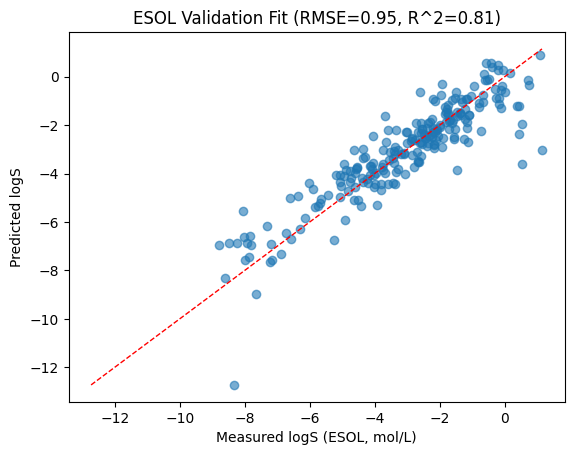

Validation plot saved to: outputs/run_20260712-054217-323176/esol_validation_plot.png


In [11]:
model.eval()
with torch.no_grad():
    val_preds = model(X_val_t).numpy().flatten()

rmse = mean_squared_error(y_val, val_preds) ** 0.5
r2 = r2_score(y_val, val_preds)
print(f"Validation RMSE: {rmse:.3f} log mol/L | R^2: {r2:.3f}")

plt.figure()
plt.scatter(y_val.flatten(), val_preds, alpha=0.6)
lims = [min(y_val.min(), val_preds.min()), max(y_val.max(), val_preds.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Measured logS (ESOL, mol/L)")
plt.ylabel("Predicted logS")
plt.title(f"ESOL Validation Fit (RMSE={rmse:.2f}, R^2={r2:.2f})")
plt.savefig(RUN_DIR / "esol_validation_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Validation plot saved to: {RUN_DIR / 'esol_validation_plot.png'}")

## 10. Apply to your anticancer compound list (inference only)\n\n**Note:** these are model *predictions*, not measured solubility values — the output CSV flags this explicitly.

In [12]:
df = pd.read_csv(anticancer_path)
print("Anticancer dataset loaded with", len(df), "rows")
print("Columns:", list(df.columns))

smiles_col_candidates = ["CanonicalSMILES", "SMILES", "canonical_smiles", "smiles"]
smiles_col = next((c for c in smiles_col_candidates if c in df.columns), None)
if smiles_col is None:
    raise KeyError(f"SMILES column not found. Tried: {smiles_col_candidates}. Available: {list(df.columns)}")

df = df.rename(columns={smiles_col: "smiles"}).dropna(subset=["smiles"])

df["features"] = df["smiles"].apply(get_features)
df = df.dropna(subset=["features"])
print("Valid anticancer molecules:", len(df))

X_infer = np.array(list(df["features"]), dtype=np.float32)
X_infer_t = torch.tensor(scale(X_infer), dtype=torch.float32)

with torch.no_grad():
    infer_preds = model(X_infer_t).numpy().flatten()

out_df = df[["smiles"]].copy()
# carry through a name/ID column if present, for readability
for id_col in ["cmpdname", "Name", "iupacname", "cid", "CID"]:
    if id_col in df.columns:
        out_df.insert(0, id_col, df[id_col])
        break

out_df["predicted_logS_mol_per_L"] = infer_preds
out_df["note"] = "MODEL PREDICTION, not a measured value"

preds_path = RUN_DIR / "anticancer_predictions.csv"
out_df.to_csv(preds_path, index=False)
print(f"Anticancer predictions saved to: {preds_path}")
out_df.sort_values("predicted_logS_mol_per_L", ascending=False).head(10)


Anticancer dataset loaded with 216 rows
Columns: ['Compound_CID', 'Name', 'Synonyms', 'Molecular_Formula', 'InChI', 'SMILES', 'InChIKey', 'IUPAC_Name', 'MeSH_Headings', 'Annotation_Content', 'Linked_BioAssays', 'Data_Source', 'Data_Source_Category', 'Tagged_by_PubChem', 'Molecular_Weight', 'Polar_Area', 'Complexity', 'XLogP', 'Heavy_Atom_Count', 'H-Bond_Donor_Count', 'H-Bond_Acceptor_Count', 'Rotatable_Bond_Count', 'Exact_Mass', 'Monoisotopic_Mass', 'Charge', 'Covalent_Unit_Count', 'Isotopic_Atom_Count', 'Total_Atom_Stereo_Count', 'Defined_Atom_Stereo_Count', 'Undefined_Atom_Stereo_Count', 'Total_Bond_Stereo_Count', 'Defined_Bond_Stereo_Count', 'Undefined_Bond_Stereo_Count', 'Linked_PubChem_Literature_Count', 'Linked_PubChem_Patent_Count', 'Linked_PubChem_Patent_Family_Count', 'Annotation_Type_Count', 'Create_Date']
Valid anticancer molecules: 216
Anticancer predictions saved to: outputs/run_20260712-054217-323176/anticancer_predictions.csv


,Name,smiles,predicted_logS_mol_per_L,note
202,N-Methyl-D-glucamine,CNC[C@@H]([C@H]([C@@H]([C@@H](CO)O)O)O)O,0.066234,"MODEL PREDICTION, not a measured value"
111,Anticancer agent 62,CN1C2=C(C=C(C=C2)S(=O)(=O)NC3=C(N=C(C=C3)OC)OC...,-1.017097,"MODEL PREDICTION, not a measured value"
103,Anticancer agent 61,CN1C2=C(C=C(C=C2)S(=O)(=O)N(CCOP(=O)([O-])[O-]...,-1.270770,"MODEL PREDICTION, not a measured value"
66,Anticancer agent 263,CC1(C(=C(C(=O)O1)C(=O)NCCO)CC[C@@H](C(=O)O)N)C,-1.625016,"MODEL PREDICTION, not a measured value"
19,Anticancer agent 188,CN1C2=NC(=O)N(C(=O)C2=NC(=N1)C3=CC=CC=C3F)C,-2.387925,"MODEL PREDICTION, not a measured value"
31,Anticancer agent 13,C1=CC=C(C=C1)CNC(=O)CC(C(=O)NCC2=CC=CC=C2)O,-2.630284,"MODEL PREDICTION, not a measured value"
163,Anticancer agent 194,COC1=CC2=C(C=C1)N(CCN2)C(=O)NCCCl,-2.730503,"MODEL PREDICTION, not a measured value"
187,Anticancer agent 202,C1=CC=C(C=C1)N2C=C(N=N2)COC3=CC=CC=C3C=N[C@@H]...,-2.747158,"MODEL PREDICTION, not a measured value"
154,Anticancer agent 154,CN1CCN(CC1)CCNC(=O)C2=NC3=C4C(=C2)C5=CC=CC=C5N...,-2.896423,"MODEL PREDICTION, not a measured value"
211,"N,N',N''-(nitrilotris(ethane-2,1-diyl))tris(2,...",C(CN(CCNC(=O)C(Cl)Cl)CCNC(=O)C(Cl)Cl)NC(=O)C(C...,-2.974340,"MODEL PREDICTION, not a measured value"


### Applicability-domain check (optional but recommended)\n\nESOL is mostly small, simple organic molecules. Many anticancer drugs (kinase inhibitors, large polycyclic scaffolds, etc.) fall outside that descriptor range, so predictions for those compounds are lower-confidence extrapolations. This flags compounds whose descriptors fall outside the ESOL training range for at least one feature.

In [13]:
train_min = X_train.min(axis=0)
train_max = X_train.max(axis=0)

out_of_domain = ((X_infer < train_min) | (X_infer > train_max)).any(axis=1)
out_df["in_esol_applicability_domain"] = ~out_of_domain

n_out = out_of_domain.sum()
print(f"{n_out} / {len(out_df)} anticancer compounds fall outside the ESOL training range "
      f"on at least one descriptor (lower-confidence predictions).")

out_df.to_csv(preds_path, index=False)  # re-save with the domain flag
out_df.head(10)


11 / 216 anticancer compounds fall outside the ESOL training range on at least one descriptor (lower-confidence predictions).


,Name,smiles,predicted_logS_mol_per_L,note,in_esol_applicability_domain
0,Anticancer agent 118,C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCN(CC4)C(=O)...,-3.815593,"MODEL PREDICTION, not a measured value",True
1,Anticancer agent 129,C1CN(C2=NC3=CC=CC=C3C(=C21)N)CC4=CC=CC=C4,-3.516480,"MODEL PREDICTION, not a measured value",True
2,Anticancer agent 84,CCN1C2=C(C=C(C=C2)C3=NC(=C(N3C4=CC=C(C=C4)OCCO...,-7.370876,"MODEL PREDICTION, not a measured value",False
3,Anticancer agent 168,CCN1C=C(C(=O)C2=CC(=C(C=C21)Cl)C3=CC=C(O3)[N+]...,-5.482485,"MODEL PREDICTION, not a measured value",True
4,Anticancer agent 3,CCN(CC)CCNC1=C2C(=C(C=C1)CN)SC3=CC=CC=C3C2=O,-3.915121,"MODEL PREDICTION, not a measured value",True
5,Anticancer agent 208,CC(C)C(=O)NC1=NN=C(S1)S(=O)(=O)N(C)CC2=CC(=C(C...,-3.992879,"MODEL PREDICTION, not a measured value",True
6,Anticancer agent 95,CC1=CC=C(C=C1)C(=O)N(CCCN)C(C2=NC3=C(C=CC(=C3)...,-5.734602,"MODEL PREDICTION, not a measured value",True
7,Anticancer agent 261,C1OC2=C(O1)C=C(C=C2)CC(CC3=CC4=C(C=C3)OCO4)NC=O,-3.161935,"MODEL PREDICTION, not a measured value",True
8,Anticancer agent 37,CC1=CC=C(C=C1)NC(=O)NC2=NC(=CS2)C3=CC(=C(C=C3)...,-4.982237,"MODEL PREDICTION, not a measured value",True
9,Anticancer agent 4,CN(C)CCNC1=C2C(=C(C=C1)CN)SC3=CC=CC=C3C2=O,-3.277260,"MODEL PREDICTION, not a measured value",True


## 11. Save model and download all results

In [14]:
torch.save(
    {
        "model_state": model.state_dict(),
        "feature_names": FEATURE_NAMES,
        "feat_mean": feat_mean,
        "feat_std": feat_std,
    },
    RUN_DIR / "model.pt",
)
print(f"Model + scaler saved to: {RUN_DIR / 'model.pt'}")

# Zip up the run directory and download it
import shutil
zip_path = shutil.make_archive(str(RUN_DIR), "zip", RUN_DIR)
print("Zipped results:", zip_path)

files.download(zip_path)


Model + scaler saved to: outputs/run_20260712-054217-323176/model.pt
Zipped results: /content/outputs/run_20260712-054217-323176.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>